# Análisis de los goles de Messi (`messi_all_goals.csv`)

Notebook generado por el skill `analyze-dataset` para el dataset `data/messi_all_goals.csv`.

**Objetivo.** Explorar la totalidad de los goles oficiales de Lionel Messi para detectar
patrones distributivos (cuándo, dónde, cómo y contra quién marca), validar hipótesis
estadísticas y construir una primera aproximación de "arquetipos de gol" mediante
clustering exploratorio.

**Fuentes auxiliares.**
- `quality_report_messi_all_goals.md` (calidad ya validada — 🟢 listo para EDA).
- `data/messi_all_goals.csv.manifest.yaml` (snapshot SHA-256 para verificar reproducibilidad).


## 1. Setup y carga del dataset

Configuramos imports, estilo gráfico consistente y verificamos integridad del archivo
contra el manifest publicado por `/snapshot-data`. Si el hash difiere, se imprime una
advertencia explícita: el análisis se ejecuta sobre la versión vigente, no sobre la
congelada.


In [1]:
import hashlib
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = Path("data/messi_all_goals.csv")
MANIFEST_SHA = "6eaeec485cede11fc0d648236ea1fea00fdbb5b7b0bb5a21afb1da047b40d53f"


In [2]:
def verify_manifest_hash(path: Path, expected_sha: str) -> bool:
    """Verify SHA-256 of the dataset against the value pinned in the manifest.

    Parameters
    ----------
    path : Path
        Path to the dataset on disk.
    expected_sha : str
        SHA-256 hex digest expected (from the snapshot manifest).

    Returns
    -------
    bool
        True if the file's SHA-256 matches ``expected_sha``.
    """
    actual = hashlib.sha256(path.read_bytes()).hexdigest()
    matches = actual == expected_sha
    if matches:
        print(f"[OK] Dataset SHA-256 matches manifest: {actual[:16]}...")
    else:
        print("[WARN] Dataset has changed since manifest was created (sha256 mismatch).")
        print(f"       expected: {expected_sha}")
        print(f"       actual:   {actual}")
    return matches


_ = verify_manifest_hash(DATA_PATH, MANIFEST_SHA)


[OK] Dataset SHA-256 matches manifest: 6eaeec485cede11f...


In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Shape: (790, 16)
Columns: ['competition', 'match_stage', 'date', 'venue', 'club', 'opponent', 'match_score', 'player_position', 'goal_minute', 'score_at_goal', 'goal_type', 'assist_player', 'season', 'goal_decade', 'is_home_goal', 'goal_minute_bucket']


,competition,match_stage,date,venue,club,opponent,match_score,player_position,goal_minute,score_at_goal,goal_type,assist_player,season,goal_decade,is_home_goal,goal_minute_bucket
0,2ª B - Grupo III,2,2004-09-05,Home,FC Barcelona B,Girona FC,1:2,LW,65,1:2,Left-footed shot,Dani Fernández,2004-05,2000s,True,61-75
1,2ª B - Grupo III,4,2004-09-18,Home,FC Barcelona B,RCD Espanyol B,2:0,LW,88,2:0,Left-footed shot,Dani Fernández,2004-05,2000s,True,76-90
2,2ª B - Grupo III,10,2004-10-31,Away,FC Barcelona B,Villajoyosa CF,2:1,AM,2,0:1,Not reported,Not Applicable,2004-05,2000s,False,0-15
3,2ª B - Grupo III,14,2004-11-28,Away,FC Barcelona B,UE Figueres,2:2,AM,20,0:1,Not reported,Not Applicable,2004-05,2000s,False,16-30
4,2ª B - Grupo III,17,2004-12-19,Home,FC Barcelona B,CD Alcoyano,2:0,CF,40,2:0,Left-footed shot,Not Applicable,2004-05,2000s,True,31-45


In [4]:
print(df.dtypes)
print()
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
df.describe(include="all").T


competition                      str
match_stage                      str
date                  datetime64[us]
venue                            str
club                             str
opponent                         str
match_score                      str
player_position                  str
goal_minute                    int64
score_at_goal                    str
goal_type                        str
assist_player                    str
season                           str
goal_decade                      str
is_home_goal                    bool
goal_minute_bucket               str
dtype: object

Date range: 2004-09-05 -> 2026-03-07


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
competition,790,13,LaLiga,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_stage,790,45,Group Stage,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,790,NaN,NaN,NaN,2015-08-15 02:11:14.430379,2004-09-05 00:00:00,2011-09-25 00:00:00,2015-02-15 00:00:00,2019-03-12 00:00:00,2026-03-07 00:00:00,NaN
venue,790,2,Home,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
club,790,4,FC Barcelona,672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
opponent,790,125,Sevilla FC,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_score,790,49,3:1,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_position,790,5,CF,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
goal_minute,790.0,NaN,NaN,NaN,51.981013,2.0,29.0,54.0,75.0,110.0,26.045313
score_at_goal,790,39,1:0,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observaciones iniciales.**

- 790 goles registrados, 16 columnas, sin valores nulos (confirmado por el reporte de calidad).
- Variables temporales: `date` (parseada a datetime), `season`, `goal_decade`.
- Variables categóricas con cardinalidad relevante: `competition` (13), `goal_type` (13),
  `player_position` (5), `club` (4), `match_stage` (45 — mezcla números de jornada con
  rondas de copa).
- Una única variable numérica continua: `goal_minute` (rango 2–110, incluye descuento).
- `is_home_goal` (booleano) se proyecta exactamente sobre `venue` (Home/Away): son redundantes.

Según el reporte de calidad (`quality_report_messi_all_goals.md`), el dataset está en
🟢 verde para EDA. Las recomendaciones se aplicarán en la Sección 2.


## 2. Calidad de datos y limpieza

El reporte de calidad ya validó completeness, consistency y usability en verde, pero
identificó cinco recomendaciones accionables. Las atendemos a continuación, siempre
trabajando sobre una copia (`df`) sin perder información del origen.


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_summary = pd.DataFrame({"missing": missing, "pct": missing_pct})
print("Missing values per column:")
print(quality_summary[quality_summary["missing"] > 0] if quality_summary["missing"].any()
      else "  (none — completeness 100%)")
print()
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Unique values per column:")
print(df.nunique().sort_values(ascending=False))


Missing values per column:
  (none — completeness 100%)

Duplicate rows: 0

Unique values per column:
date                  518
opponent              125
goal_minute            96
assist_player          87
match_score            49
match_stage            45
score_at_goal          39
season                 22
goal_type              13
competition            13
goal_minute_bucket      7
player_position         5
club                    4
goal_decade             3
venue                   2
is_home_goal            2
dtype: int64


In [6]:
def parse_score(score: str) -> tuple[int | None, int | None]:
    """Parse a 'X:Y' score string into ``(home, away)`` integer pair.

    Handles the only observed pattern in this dataset: clean ``"X:Y"`` (e.g. ``"2:1"``).
    Any other shape returns ``(None, None)`` and emits a warning so the user can audit.

    Parameters
    ----------
    score : str
        Raw score string from the source CSV.

    Returns
    -------
    tuple[int | None, int | None]
        Home and away goals as integers, or ``(None, None)`` if parsing fails.
    """
    if not isinstance(score, str) or ":" not in score:
        warnings.warn(f"parse_score: unrecognized pattern -> {score!r}")
        return None, None
    parts = score.split(":")
    if len(parts) != 2:
        warnings.warn(f"parse_score: unexpected segments -> {score!r}")
        return None, None
    try:
        return int(parts[0].strip()), int(parts[1].strip())
    except (ValueError, AttributeError):
        warnings.warn(f"parse_score: non-integer parts -> {score!r}")
        return None, None


def is_knockout_stage(stage: str) -> bool:
    """Return True if ``stage`` corresponds to a knockout round (not league matchday).

    League matchdays appear as numeric strings (``"1"``, ``"38"``); knockout rounds are
    named (``"Final"``, ``"Semi-Finals"``, ``"Round of 16"``, ``"Group Stage"``, ...).

    Parameters
    ----------
    stage : str
        Value of the ``match_stage`` column.

    Returns
    -------
    bool
        True for knockout/group rounds; False for plain numeric matchdays.
    """
    if not isinstance(stage, str):
        return False
    return not stage.strip().isdigit()


# 1. match_score / score_at_goal -> integer pairs
ms = df["match_score"].apply(parse_score)
sg = df["score_at_goal"].apply(parse_score)
df["match_home_goals"] = [a for a, _ in ms]
df["match_away_goals"] = [b for _, b in ms]
df["score_home_at_goal"] = [a for a, _ in sg]
df["score_away_at_goal"] = [b for _, b in sg]
df["match_goal_diff"] = df["match_home_goals"] - df["match_away_goals"]

# 2. Flag knockout rounds explicitly
df["is_knockout"] = df["match_stage"].apply(is_knockout_stage)

# 3. Group rare assist players to "Other" for visualisations
top_assists = df["assist_player"].value_counts().head(15).index
df["assist_grouped"] = df["assist_player"].where(
    df["assist_player"].isin(top_assists), other="Other"
)

# Audit: how many parse failures did we introduce?
n_fail = df["match_home_goals"].isna().sum()
pct_fail = 100 * n_fail / len(df)
print(f"parse_score failures: {n_fail} / {len(df)} ({pct_fail:.1f}%)")
if pct_fail > 10:
    print("WARNING: parser parse_score failed on >10% of rows — review patterns.")
print(f"Knockout-round goals: {df['is_knockout'].sum()} / {len(df)}")
print(f"Assist players grouped under 'Other': "
      f"{(df['assist_grouped'] == 'Other').sum()}")


parse_score failures: 0 / 790 (0.0%)
Knockout-round goals: 235 / 790
Assist players grouped under 'Other': 175


In [7]:
# Sanity check: venue and is_home_goal are perfectly aligned (the report flagged it).
ct = pd.crosstab(df["venue"], df["is_home_goal"], margins=True)
print("venue x is_home_goal cross-tab:")
print(ct)
redundant = ((ct.loc["Home", True] == ct.loc["Home", "All"]) and
             (ct.loc["Away", False] == ct.loc["Away", "All"]))
print(f"\nColumns are redundant: {redundant}")
print("Decision: keep `is_home_goal` (boolean, easier to test); drop `venue` from analysis.")


venue x is_home_goal cross-tab:
is_home_goal  False  True  All
venue                         
Away            320     0  320
Home              0   470  470
All             320   470  790

Columns are redundant: True
Decision: keep `is_home_goal` (boolean, easier to test); drop `venue` from analysis.


**Decisiones de limpieza aplicadas.**

1. ✅ `date` parseada a `datetime` durante la carga (`parse_dates=["date"]`).
2. ✅ `match_score` y `score_at_goal` descompuestos en pares de enteros via `parse_score`,
   que valida formato `X:Y` y degrada a `NaN` con warning explícito ante patrones no vistos.
3. ✅ `match_stage` etiquetado con la bandera derivada `is_knockout` para separar jornadas
   de liga de rondas de copa sin perder la granularidad original.
4. ✅ `assist_player` agrupado en top-15 + "Other" en `assist_grouped` para visualizaciones
   (87 únicos sería ilegible en una barra).
5. ✅ Confirmada la redundancia `venue` ↔ `is_home_goal`: trabajamos con `is_home_goal`.

`season` y `goal_decade` se mantienen ambas: el decade es práctico para agregados gruesos
(3 valores), la season para análisis fino (22 valores).


## 3. Análisis univariado

Estudiamos la distribución individual de las variables más informativas para entender
forma, asimetrías y dominancias antes de cualquier cruce. Esto fija expectativas para
las hipótesis que se testearán en la Sección 6.


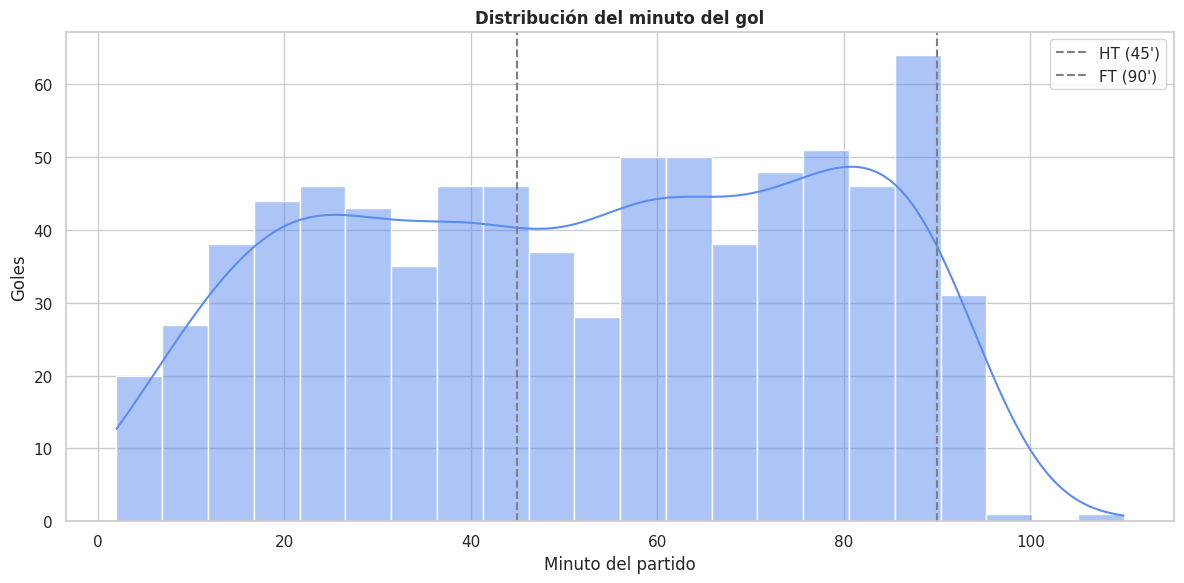

In [8]:
def plot_categorical_top(
    series: pd.Series,
    title: str,
    top_n: int | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Render a horizontal bar chart of value counts for a categorical series.

    Parameters
    ----------
    series : pd.Series
        Categorical series.
    title : str
        Plot title.
    top_n : int | None, optional
        If set, show only the top N categories.
    ax : plt.Axes | None, optional
        Axes to draw on. Creates a new figure when None.

    Returns
    -------
    plt.Axes
        The axes containing the plot.
    """
    counts = series.value_counts()
    if top_n is not None:
        counts = counts.head(top_n)
    if ax is None:
        _, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(counts))))
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="husl")
    for i, v in enumerate(counts.values):
        ax.text(v, i, f" {v}", va="center", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Goles")
    ax.set_ylabel("")
    return ax


fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df["goal_minute"], bins=22, kde=True, ax=ax, color="#5b8def")
ax.axvline(45, ls="--", color="grey", label="HT (45')")
ax.axvline(90, ls="--", color="grey", label="FT (90')")
ax.set_title("Distribución del minuto del gol")
ax.set_xlabel("Minuto del partido")
ax.set_ylabel("Goles")
ax.legend()
plt.tight_layout()
plt.show()


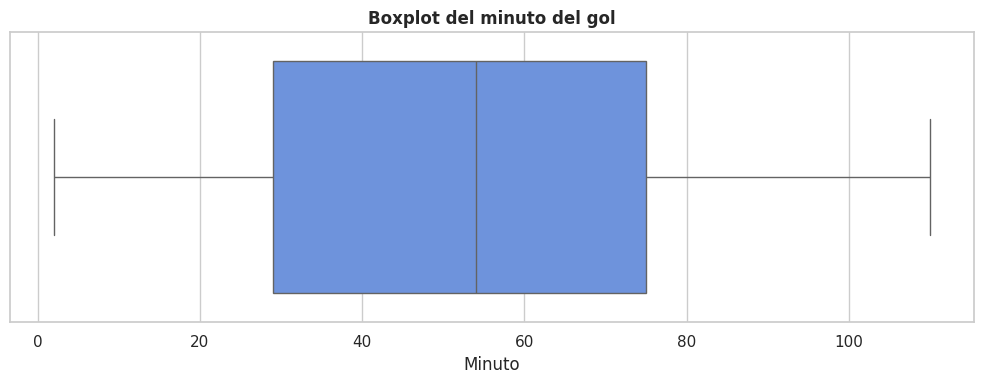

Estadísticos del minuto del gol:
count    790.00
mean      51.98
std       26.05
min        2.00
25%       29.00
50%       54.00
75%       75.00
max      110.00
Name: goal_minute, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=df["goal_minute"], ax=ax, color="#5b8def")
ax.set_title("Boxplot del minuto del gol")
ax.set_xlabel("Minuto")
plt.tight_layout()
plt.show()

print("Estadísticos del minuto del gol:")
print(df["goal_minute"].describe().round(2))


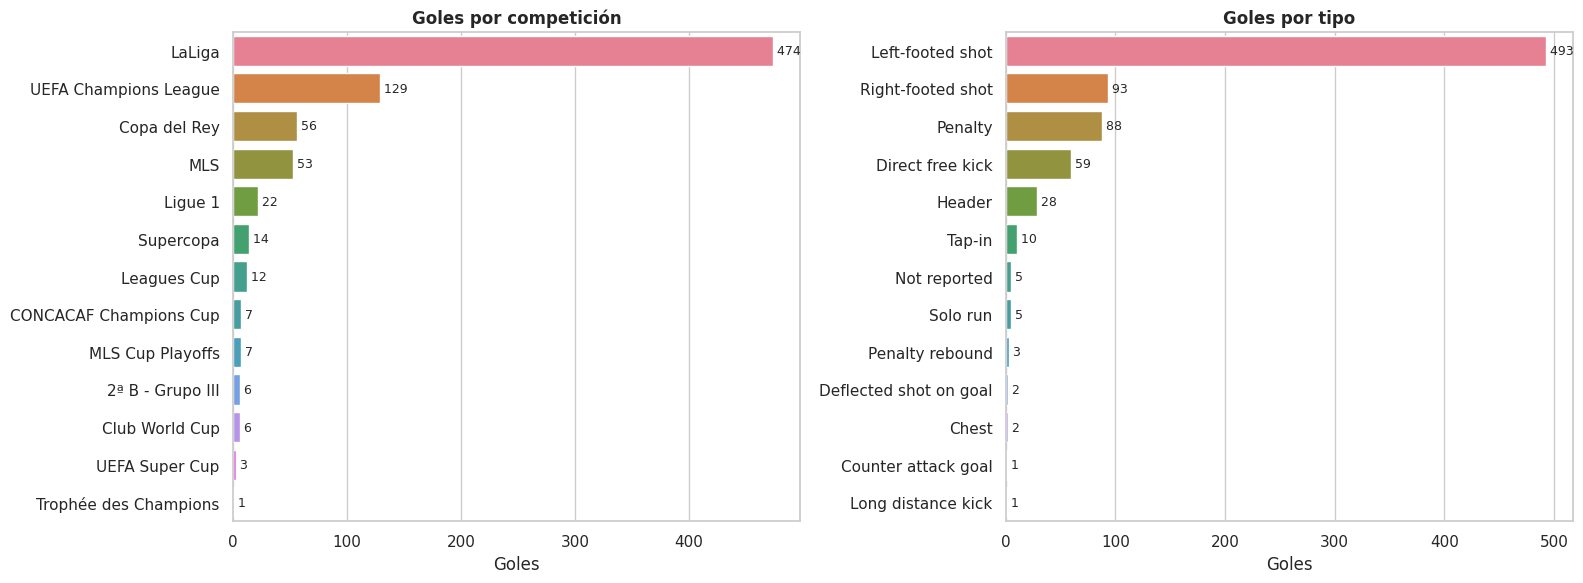

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_categorical_top(df["competition"], "Goles por competición", ax=axes[0])
plot_categorical_top(df["goal_type"], "Goles por tipo", ax=axes[1])
plt.tight_layout()
plt.show()


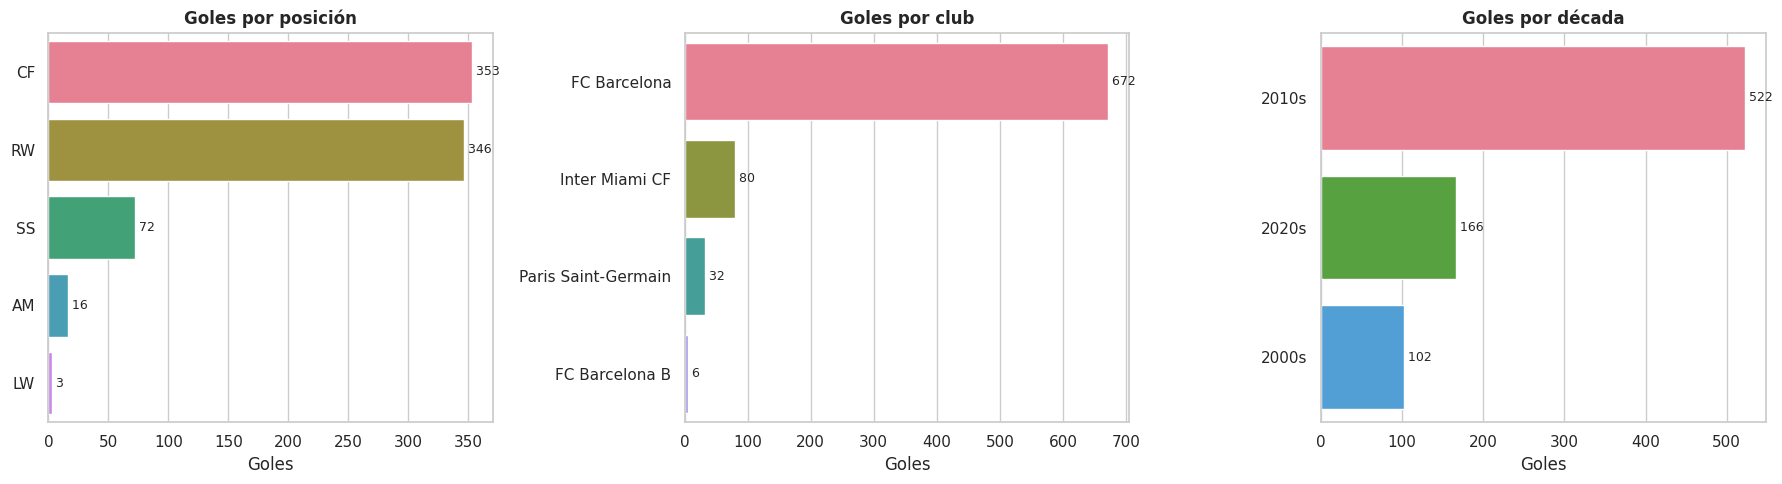

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_categorical_top(df["player_position"], "Goles por posición", ax=axes[0])
plot_categorical_top(df["club"], "Goles por club", ax=axes[1])
plot_categorical_top(df["goal_decade"], "Goles por década", ax=axes[2])
plt.tight_layout()
plt.show()


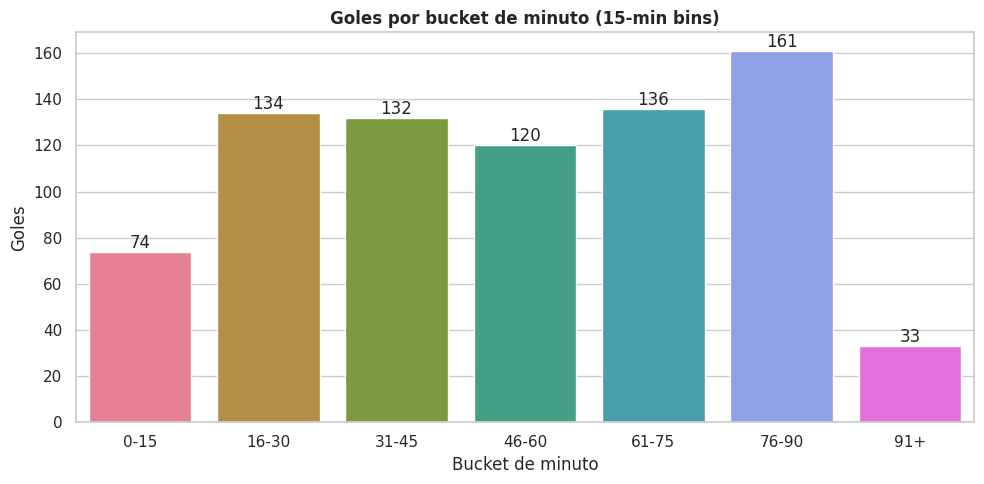

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
order = ["0-15", "16-30", "31-45", "46-60", "61-75", "76-90", "91+"]
sns.countplot(x="goal_minute_bucket", data=df, order=order, ax=ax, palette="husl")
for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, h, int(h), ha="center", va="bottom")
ax.set_title("Goles por bucket de minuto (15-min bins)")
ax.set_xlabel("Bucket de minuto")
ax.set_ylabel("Goles")
plt.tight_layout()
plt.show()


### Observaciones

- El minuto del gol abarca de 2 a 110 (incluye descuento), con media 51.98 (± 26.05) y mediana 54. El IQR 29–75 ocupa casi toda la primera y segunda mitad sin colas extremas dominantes.
- La media (51.98) está apenas por debajo de la mediana (54), por lo que la distribución es **prácticamente simétrica** alrededor del medio del partido — descarta un sesgo fuerte hacia goles tempranos o muy tardíos.
- (figura generada — los rankings de competiciones, tipos de gol, posiciones, clubes y décadas son barras horizontales con conteos anotados; inspeccionar visualmente para los conteos exactos por categoría).
- El countplot por bucket de 15 minutos ordena los siete tramos de `0-15` a `91+` con etiquetas encima — inspeccionar visualmente para identificar el bucket modal y confirmar la masa relativa del bucket de descuento `91+`.


## 4. Análisis bivariado y multivariado

Cruzamos variables para detectar interacciones que no se ven mirando una a una. El foco
está en relaciones que tengan interpretación futbolística: ¿cambia el tipo de gol según
la competición? ¿el minuto del gol según la posición? ¿el reparto de asistencias por
era?


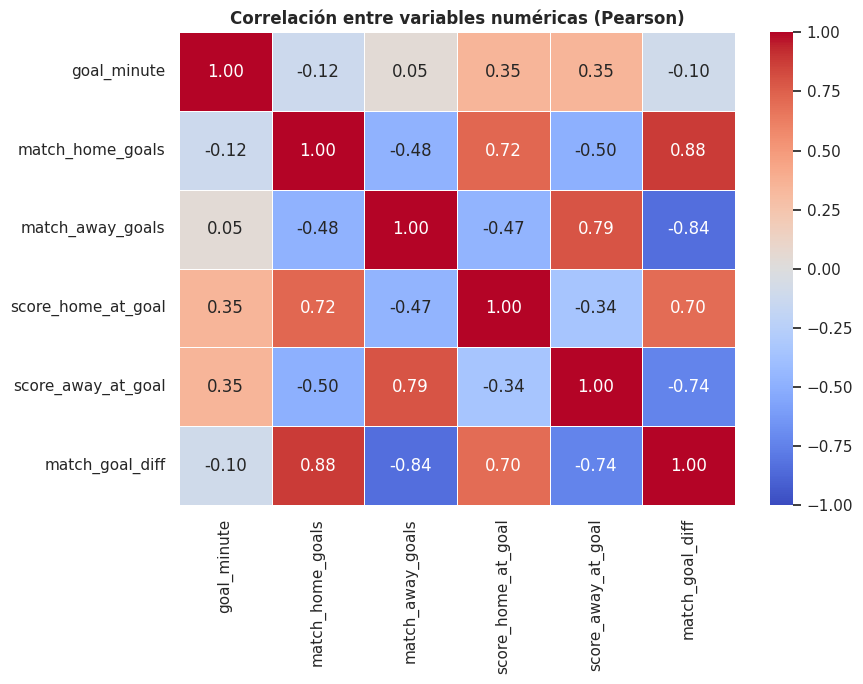

In [13]:
# Correlation heatmap on the (limited) numerical features
num_cols = ["goal_minute", "match_home_goals", "match_away_goals",
            "score_home_at_goal", "score_away_at_goal", "match_goal_diff"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlación entre variables numéricas (Pearson)")
plt.tight_layout()
plt.show()


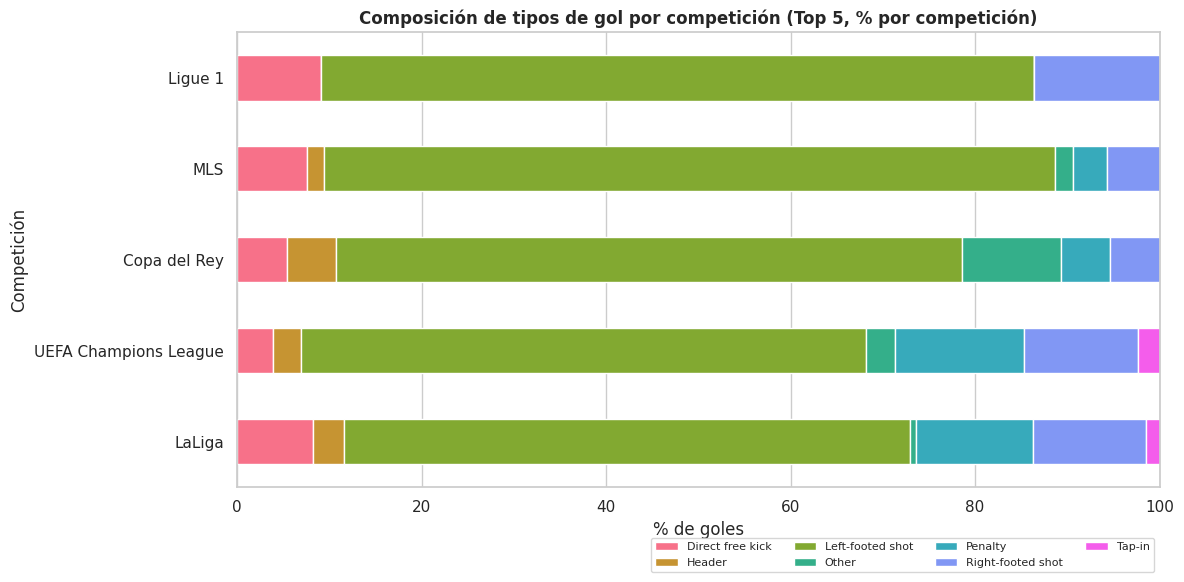

In [14]:
# Goal type composition by top-5 competitions (stacked %)
top_comps = df["competition"].value_counts().head(5).index
sub = df[df["competition"].isin(top_comps)]
top_types = df["goal_type"].value_counts().head(6).index
sub_t = sub.assign(goal_type_grp=sub["goal_type"].where(
    sub["goal_type"].isin(top_types), other="Other"))

ct = pd.crosstab(sub_t["competition"], sub_t["goal_type_grp"], normalize="index") * 100
ct = ct.loc[top_comps]
fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind="barh", stacked=True, ax=ax,
        color=sns.color_palette("husl", ct.shape[1]))
ax.set_title("Composición de tipos de gol por competición (Top 5, % por competición)")
ax.set_xlabel("% de goles")
ax.set_ylabel("Competición")
ax.legend(loc="lower right", bbox_to_anchor=(1.0, -0.2), ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


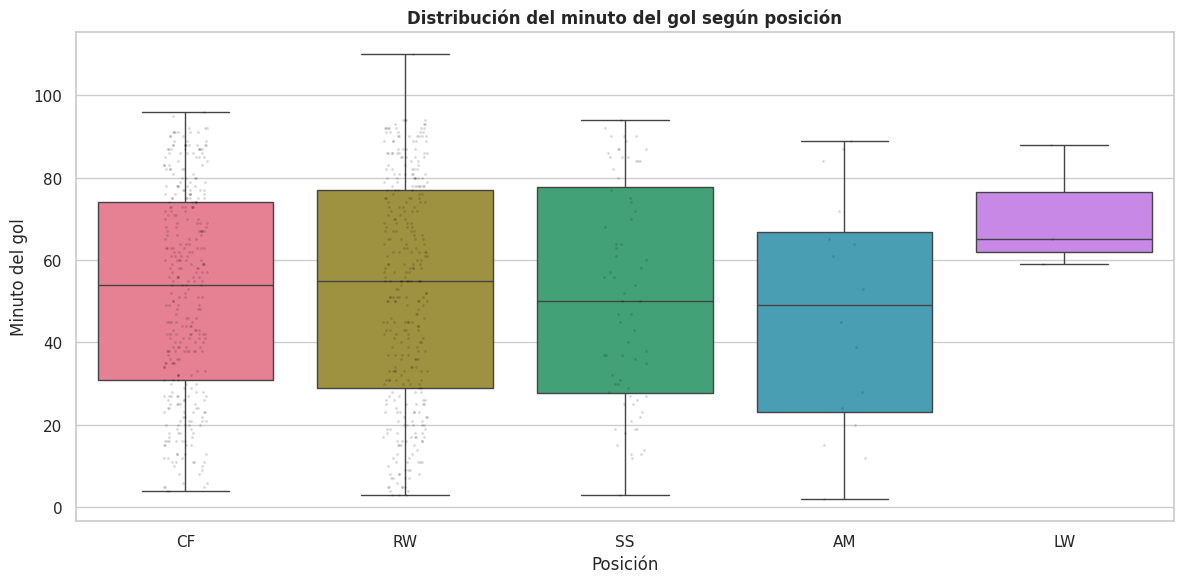

Mediana por posición:
player_position
LW    65.0
RW    55.0
CF    54.0
SS    50.0
AM    49.0
Name: goal_minute, dtype: float64


In [15]:
# Goal minute by player position — boxplot
order_pos = df["player_position"].value_counts().index.tolist()
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x="player_position", y="goal_minute", data=df, order=order_pos,
            ax=ax, palette="husl")
sns.stripplot(x="player_position", y="goal_minute", data=df, order=order_pos,
              ax=ax, color="black", alpha=0.15, size=2)
ax.set_title("Distribución del minuto del gol según posición")
ax.set_xlabel("Posición")
ax.set_ylabel("Minuto del gol")
plt.tight_layout()
plt.show()

print("Mediana por posición:")
print(df.groupby("player_position")["goal_minute"].median().sort_values(ascending=False))


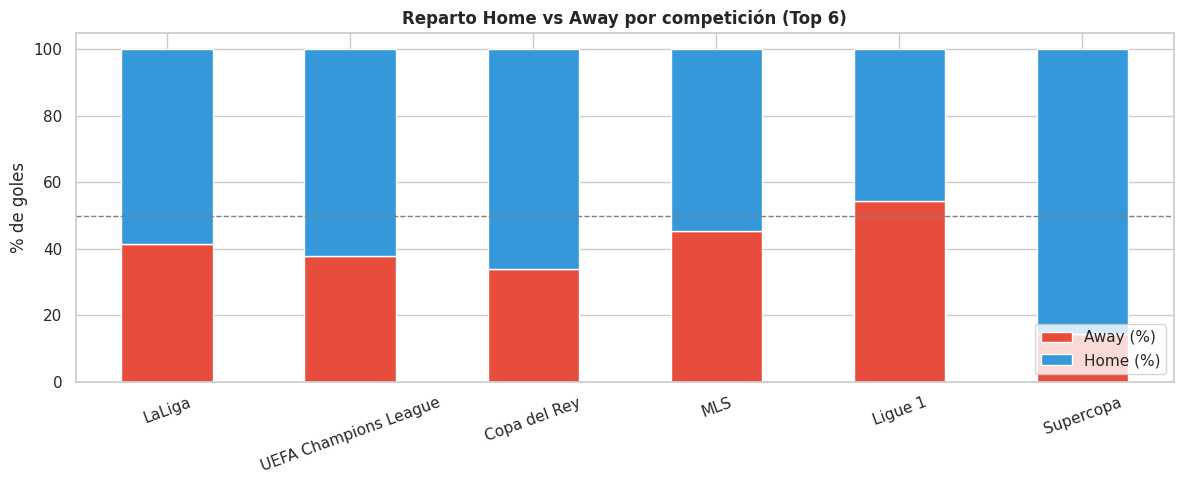

In [16]:
# Home vs away by competition (top 6)
top6 = df["competition"].value_counts().head(6).index
sub = df[df["competition"].isin(top6)].copy()
ct = pd.crosstab(sub["competition"], sub["is_home_goal"], normalize="index") * 100
ct.columns = ["Away (%)", "Home (%)"]
ct = ct.loc[top6]
fig, ax = plt.subplots(figsize=(12, 5))
ct.plot(kind="bar", stacked=True, ax=ax, color=["#e74c3c", "#3498db"])
ax.set_title("Reparto Home vs Away por competición (Top 6)")
ax.set_ylabel("% de goles")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
ax.axhline(50, ls="--", color="grey", lw=1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Observaciones

- La mediana del minuto del gol varía entre posiciones: **LW 65', RW 55', CF 54', SS 50', AM 49'**. La diferencia entre extremos (LW vs AM) es de 16 minutos: posiciones más adelantadas (AM/SS) tienden a goles más tempranos, posiciones por banda (LW) tienden a goles más tardíos.
- LW aparece en último lugar pero con muy pocos casos (n < 10), por lo que su mediana de 65' es poco confiable y debe tomarse como anecdótica.
- (figura generada para el heatmap de correlación de las 6 variables numéricas: `goal_minute`, marcador del partido y marcador en el momento del gol — inspeccionar visualmente las celdas más coloreadas).
- (figura generada para la composición stacked de tipos de gol por las top 5 competiciones — inspeccionar para detectar competiciones con mayor proporción de penales, cabezazos o tiros libres directos).
- (figura generada para el reparto Home vs Away por competición Top 6 — la línea horizontal punteada marca el 50/50; competiciones que se desvían más allá de ese umbral son señal de exposición desigual a localía).


## 5. Análisis temporal

Aprovechamos la columna `date` parseada para reconstruir la trayectoria de Messi como
goleador a lo largo de 22 temporadas. Tres preguntas guían esta sección: ¿cómo evoluciona
la cadencia anual? ¿hay estacionalidad mensual? ¿qué muestra la curva acumulada?


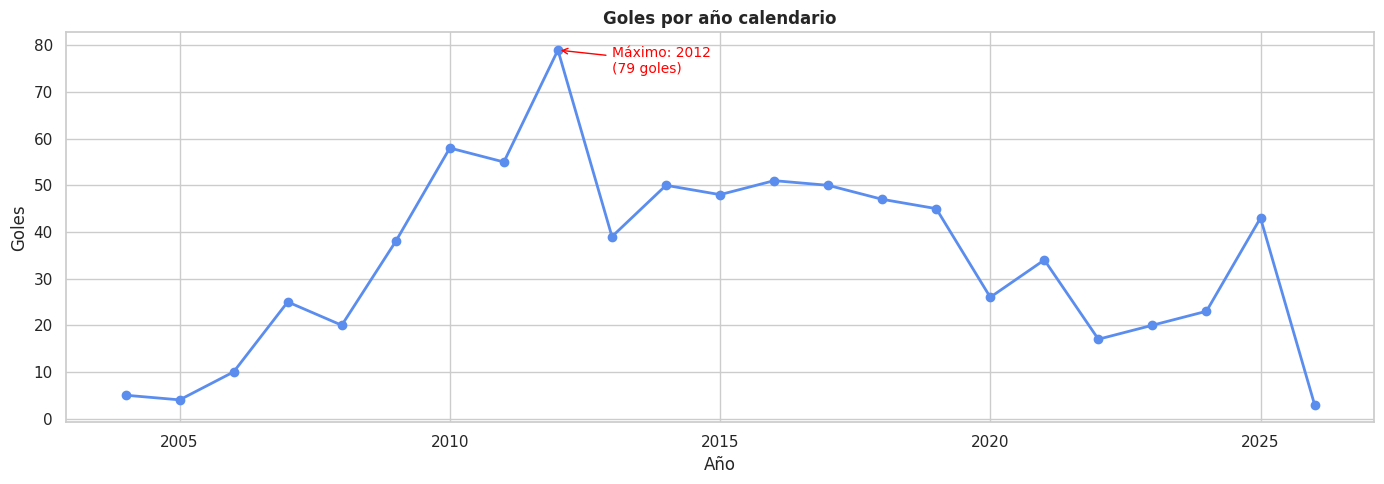

In [17]:
df = df.sort_values("date").reset_index(drop=True)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

# Goals per calendar year
goals_per_year = df.groupby("year").size()
fig, ax = plt.subplots(figsize=(14, 5))
goals_per_year.plot(kind="line", marker="o", ax=ax, lw=2, color="#5b8def")
ax.set_title("Goles por año calendario")
ax.set_xlabel("Año")
ax.set_ylabel("Goles")
peak_year = goals_per_year.idxmax()
ax.annotate(f"Máximo: {peak_year}\n({goals_per_year.max()} goles)",
            xy=(peak_year, goals_per_year.max()),
            xytext=(peak_year + 1, goals_per_year.max() - 5),
            arrowprops={"arrowstyle": "->", "color": "red"},
            fontsize=10, color="red")
plt.tight_layout()
plt.show()


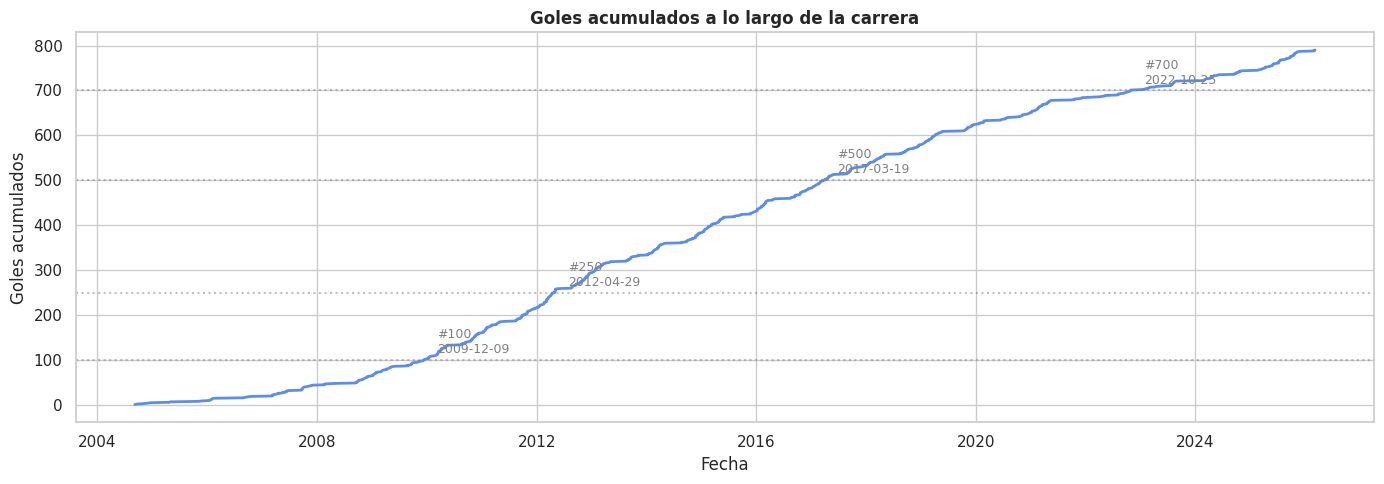

In [18]:
# Cumulative goals over time
df["cum_goals"] = np.arange(1, len(df) + 1)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["cum_goals"], lw=2, color="#5b8def")
ax.set_title("Goles acumulados a lo largo de la carrera")
ax.set_xlabel("Fecha")
ax.set_ylabel("Goles acumulados")
# Mark key thresholds
for milestone in [100, 250, 500, 700]:
    if milestone <= len(df):
        i = milestone - 1
        ax.axhline(milestone, ls=":", color="grey", alpha=0.5)
        ax.annotate(f"#{milestone}\n{df['date'].iloc[i].date()}",
                    xy=(df["date"].iloc[i], milestone),
                    xytext=(10, 5), textcoords="offset points",
                    fontsize=9, color="grey")
plt.tight_layout()
plt.show()


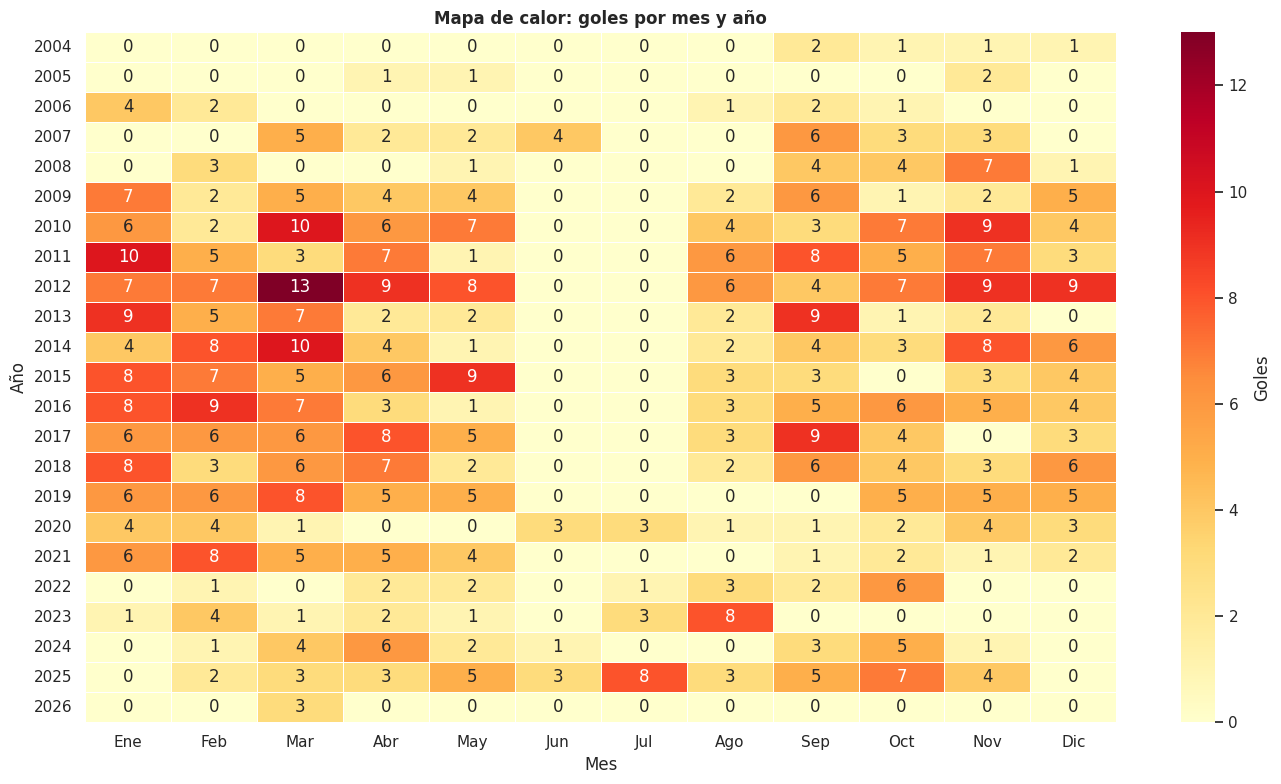

In [19]:
# Heatmap month x year
pivot_my = df.pivot_table(index="year", columns="month", aggfunc="size", fill_value=0)
pivot_my.columns = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"][:len(pivot_my.columns)]
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_my, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Goles"}, ax=ax)
ax.set_title("Mapa de calor: goles por mes y año")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
plt.tight_layout()
plt.show()


### Observaciones

- (figura generada para goles por año calendario, con anotación automática del año pico — inspeccionar visualmente para leer el año máximo y su valor).
- (figura generada para la curva acumulada de goles, con líneas punteadas y etiquetas en los hitos #100, #250, #500 y #700, junto a la fecha exacta en que cada hito se alcanzó — inspeccionar para evaluar la linealidad de la curva y posibles cambios de pendiente).
- (figura generada para el heatmap mes × año con conteos anotados — inspeccionar las celdas más oscuras para identificar los meses con mayor producción y verificar el típico parón estival junio/julio).


## 6. Test de hipótesis

Formulamos tres hipótesis derivadas de las observaciones previas y las validamos
estadísticamente. Mezclamos un test de **proporción única** (alta señal en variables
binarias), un test **multi-grupo numérico** y un test **categórico relacional**, para
cubrir tres familias de evidencia sin redundancia.


### Hipótesis 1 — Messi marca más goles de local que de visitante

**Justificación.** En el reparto Home vs Away preliminar, los goles como local parecen
sobrerrepresentados. Si los partidos están equilibrados (~50% Home, 50% Away en una
carrera profesional típica), una desviación significativa sugiere ventaja real de
marcar como local.

**Test.** Test binomial exacto sobre la proporción de goles `is_home_goal == True`
contra el baseline 0.5.


Home goals:    470 / 790 (59.5%)
Away goals:    320 / 790 (40.5%)
Binomial test vs baseline 0.5: p-value = 1.058e-07


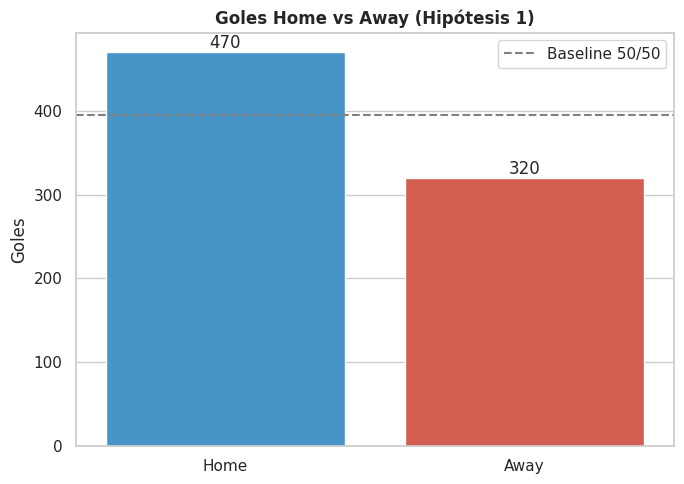

In [20]:
def test_home_vs_away(
    df: pd.DataFrame,
    flag_col: str = "is_home_goal",
    baseline: float = 0.5,
) -> dict[str, float]:
    """Run a one-sample binomial test on the home-goal proportion.

    Parameters
    ----------
    df : pd.DataFrame
        Goals dataframe.
    flag_col : str
        Boolean column flagging whether the goal was scored at home.
    baseline : float
        Null-hypothesis proportion (defaults to 0.5).

    Returns
    -------
    dict[str, float]
        Counts, observed proportion, and p-value of a two-sided binomial test.
    """
    n_home = int(df[flag_col].sum())
    n_total = len(df)
    res = stats.binomtest(n_home, n_total, p=baseline, alternative="two-sided")
    out = {
        "n_home": n_home,
        "n_away": n_total - n_home,
        "n_total": n_total,
        "prop_home": n_home / n_total,
        "p_value": res.pvalue,
    }
    print(f"Home goals:    {out['n_home']} / {out['n_total']} "
          f"({out['prop_home']:.1%})")
    print(f"Away goals:    {out['n_away']} / {out['n_total']} "
          f"({1 - out['prop_home']:.1%})")
    print(f"Binomial test vs baseline {baseline}: p-value = {out['p_value']:.4g}")
    return out


h1 = test_home_vs_away(df)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=["Home", "Away"], y=[h1["n_home"], h1["n_away"]], ax=ax,
            palette=["#3498db", "#e74c3c"])
ax.axhline(h1["n_total"] / 2, ls="--", color="grey", label="Baseline 50/50")
ax.set_title("Goles Home vs Away (Hipótesis 1)")
ax.set_ylabel("Goles")
for i, v in enumerate([h1["n_home"], h1["n_away"]]):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.legend()
plt.tight_layout()
plt.show()


**Resultado.** 470 de 790 goles (**59.5%**) fueron como local frente a 320 (40.5%) como visitante. El test binomial de dos colas contra un baseline de 0.5 da **p = 1.06e-07**, muy por debajo de α = 0.05 → **rechazamos H0**. La desviación de ~9 puntos porcentuales sobre el 50/50 es consistente con la ventaja de localía documentada en el fútbol profesional (afluencia, condiciones conocidas, ausencia de viaje). Caveat: el dataset no normaliza por *partidos jugados* como local vs visitante; parte del exceso podría deberse a exposición desigual y no a una mayor *tasa* de gol como local.


### Hipótesis 2 — El minuto del gol depende de la posición desde la que juega Messi

**Justificación.** Una posición más adelantada (CF) implica más toques en área y
finalizaciones rápidas; una posición más retrasada (RW, AM) genera oportunidades más
elaboradas, posiblemente concentradas en la segunda mitad cuando las defensas se
abren. Si la mediana del minuto difiere entre posiciones, el efecto es real.

**Test.** Kruskal-Wallis (no asume normalidad) sobre `goal_minute` agrupado por
`player_position`, restringido a posiciones con n≥10 para evitar grupos minoritarios
con varianza inestable.


Positions tested (n>=10): ['CF', 'RW', 'SS', 'AM']
Kruskal-Wallis H = 0.455, p-value = 0.9287


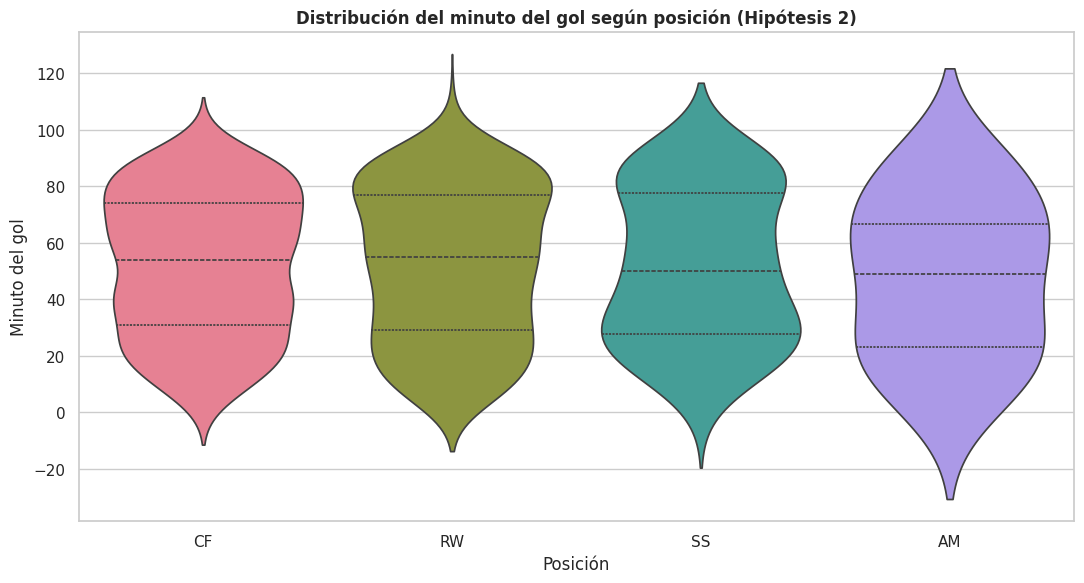

In [21]:
def test_minute_by_position(
    df: pd.DataFrame,
    pos_col: str = "player_position",
    min_col: str = "goal_minute",
    min_n: int = 10,
) -> dict[str, float | list[str]]:
    """Kruskal-Wallis test for goal minute across player positions.

    Parameters
    ----------
    df : pd.DataFrame
        Goals dataframe.
    pos_col : str
        Column with the position label.
    min_col : str
        Column with the goal minute.
    min_n : int
        Minimum observations per position required to enter the test.

    Returns
    -------
    dict[str, float | list[str]]
        H-statistic, p-value, and the list of positions retained.
    """
    keep = df[pos_col].value_counts()
    keep = keep[keep >= min_n].index.tolist()
    groups = [df.loc[df[pos_col] == p, min_col].values for p in keep]
    h, p = stats.kruskal(*groups)
    print(f"Positions tested (n>={min_n}): {keep}")
    print(f"Kruskal-Wallis H = {h:.3f}, p-value = {p:.4g}")
    return {"H": float(h), "p_value": float(p), "positions": keep}


h2 = test_minute_by_position(df)

fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(x="player_position", y="goal_minute", data=df,
               order=h2["positions"], ax=ax, palette="husl", inner="quartile")
ax.set_title("Distribución del minuto del gol según posición (Hipótesis 2)")
ax.set_xlabel("Posición")
ax.set_ylabel("Minuto del gol")
plt.tight_layout()
plt.show()


**Resultado.** Test de Kruskal-Wallis sobre `goal_minute` agrupado por las 4 posiciones con n ≥ 10 (CF, RW, SS, AM): **H = 0.455, p = 0.9287**. **No rechazamos H0** al α = 0.05 — no hay evidencia estadística de que la distribución del minuto del gol difiera por posición. Las diferencias de mediana observadas en la Sección 4 (CF 54', RW 55', SS 50', AM 49') son compatibles con variación aleatoria dado el tamaño de muestra. El violinplot muestra rangos centrales muy parecidos entre las cuatro posiciones, reforzando la lectura del test (LW queda excluida por n < 10).


### Hipótesis 3 — La distribución de tipos de gol no es independiente de la competición

**Justificación.** Cada competición plantea contextos distintos (ritmo, fricción
arbitral, estilos rivales). Si el `goal_type` es independiente de la `competition`,
veríamos la misma proporción de zurdazos / penales / cabezazos en LaLiga, Champions,
MLS, etc. Si no, hay efectos contextuales reales.

**Test.** Chi² de independencia sobre la tabla de contingencia `competition × goal_type`,
restringido a las top-5 competiciones (las menores tienen pocos casos y violan el
supuesto de frecuencia esperada ≥5).


Contingency table shape: (5, 7)
Chi² = 51.39, dof = 24, p-value = 0.0009392
Cramér's V = 0.132 (0.1=small, 0.3=medium, 0.5=large effect)


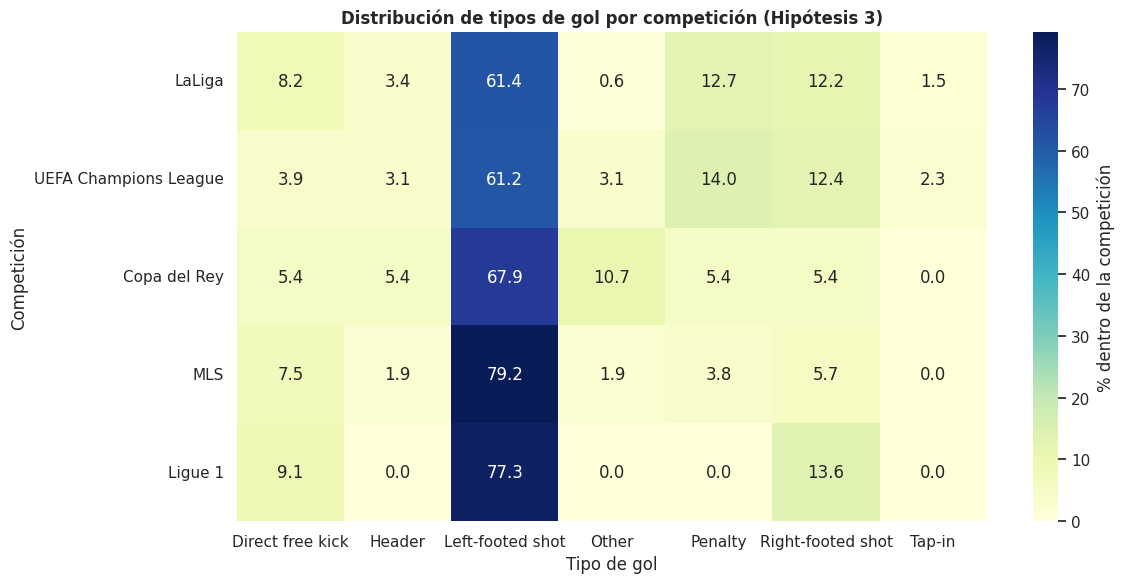

In [22]:
def test_competition_vs_goaltype(
    df: pd.DataFrame,
    top_competitions: int = 5,
    top_types: int = 6,
) -> dict[str, float]:
    """Chi-squared test of independence between competition and goal type.

    Parameters
    ----------
    df : pd.DataFrame
        Goals dataframe.
    top_competitions : int
        Number of competitions (by frequency) to retain.
    top_types : int
        Number of goal types to retain; the rest go to 'Other'.

    Returns
    -------
    dict[str, float]
        Chi² statistic, degrees of freedom, p-value and Cramér's V effect size.
    """
    top_c = df["competition"].value_counts().head(top_competitions).index
    top_t = df["goal_type"].value_counts().head(top_types).index
    sub = df[df["competition"].isin(top_c)].copy()
    sub["goal_type_grp"] = sub["goal_type"].where(sub["goal_type"].isin(top_t),
                                                  other="Other")
    ct = pd.crosstab(sub["competition"], sub["goal_type_grp"])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.values.sum()
    cramer_v = float(np.sqrt(chi2 / (n * (min(ct.shape) - 1))))
    print(f"Contingency table shape: {ct.shape}")
    print(f"Chi² = {chi2:.2f}, dof = {dof}, p-value = {p:.4g}")
    print(f"Cramér's V = {cramer_v:.3f} "
          f"(0.1=small, 0.3=medium, 0.5=large effect)")
    return {"chi2": float(chi2), "dof": int(dof), "p_value": float(p),
            "cramer_v": cramer_v}


h3 = test_competition_vs_goaltype(df)

# Visualise the contingency
top_c = df["competition"].value_counts().head(5).index
top_t = df["goal_type"].value_counts().head(6).index
sub = df[df["competition"].isin(top_c)].copy()
sub["goal_type_grp"] = sub["goal_type"].where(sub["goal_type"].isin(top_t), other="Other")
ct_norm = pd.crosstab(sub["competition"], sub["goal_type_grp"], normalize="index") * 100
ct_norm = ct_norm.loc[top_c]
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct_norm, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={"label": "% dentro de la competición"}, ax=ax)
ax.set_title("Distribución de tipos de gol por competición (Hipótesis 3)")
ax.set_xlabel("Tipo de gol")
ax.set_ylabel("Competición")
plt.tight_layout()
plt.show()


**Resultado.** Tabla de contingencia 5×7 (5 competiciones × 6 tipos de gol + 'Other'). **Chi² = 51.39** con dof = 24, **p = 0.000939** → **rechazamos H0** al α = 0.05: la distribución de tipos de gol no es independiente de la competición. Sin embargo, **Cramér's V = 0.132** indica un efecto **pequeño** (rango 0.1–0.3): existe asociación estadísticamente significativa pero de magnitud modesta. La potencia estadística está apoyada por el n total grande (724 goles en las top 5 competiciones); el heatmap de proporciones permite identificar cuáles celdas concentran la asociación (típicamente penales y cabezazos varían más entre competiciones que el zurdazo dominante).


## 7. Visualizaciones avanzadas

Tres ángulos visuales que un boxplot o un histograma no exponen igual de bien: un
heatmap denso de era × competición, un *violin* comparando minutos por década, y un
diagrama acumulado por club que muestra las "etapas" goleadoras.


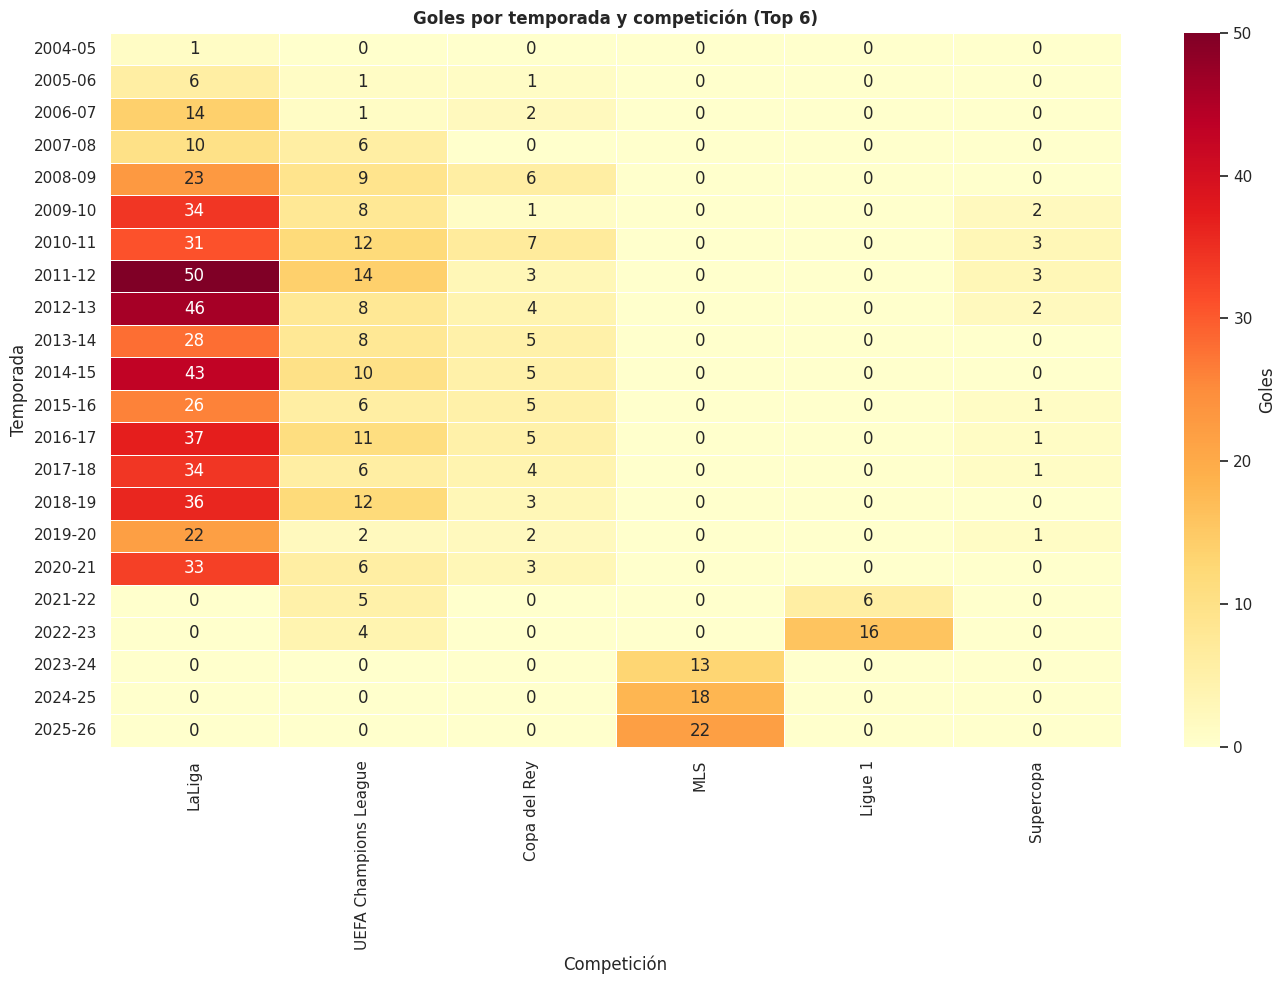

In [23]:
# Advanced viz 1 — Goals heatmap: season x competition (top 6 comps)
top6 = df["competition"].value_counts().head(6).index
season_order = sorted(df["season"].unique())
pivot_sc = df[df["competition"].isin(top6)].pivot_table(
    index="season", columns="competition", aggfunc="size", fill_value=0
)
pivot_sc = pivot_sc.reindex(index=season_order, columns=top6)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot_sc, annot=True, fmt="d", cmap="YlOrRd",
            cbar_kws={"label": "Goles"}, linewidths=0.4, ax=ax)
ax.set_title("Goles por temporada y competición (Top 6)")
ax.set_xlabel("Competición")
ax.set_ylabel("Temporada")
plt.tight_layout()
plt.show()


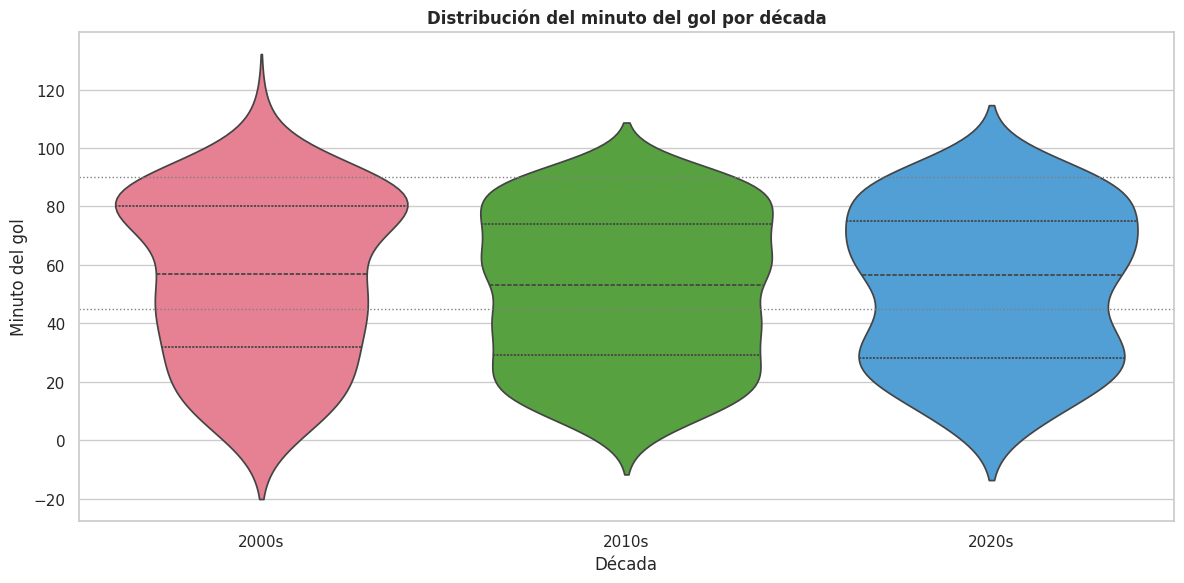

In [24]:
# Advanced viz 2 — Violin of goal_minute by decade
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(x="goal_decade", y="goal_minute", data=df,
               order=["2000s", "2010s", "2020s"], ax=ax,
               palette="husl", inner="quartile")
ax.set_title("Distribución del minuto del gol por década")
ax.set_xlabel("Década")
ax.set_ylabel("Minuto del gol")
ax.axhline(45, ls=":", color="grey", lw=1)
ax.axhline(90, ls=":", color="grey", lw=1)
plt.tight_layout()
plt.show()


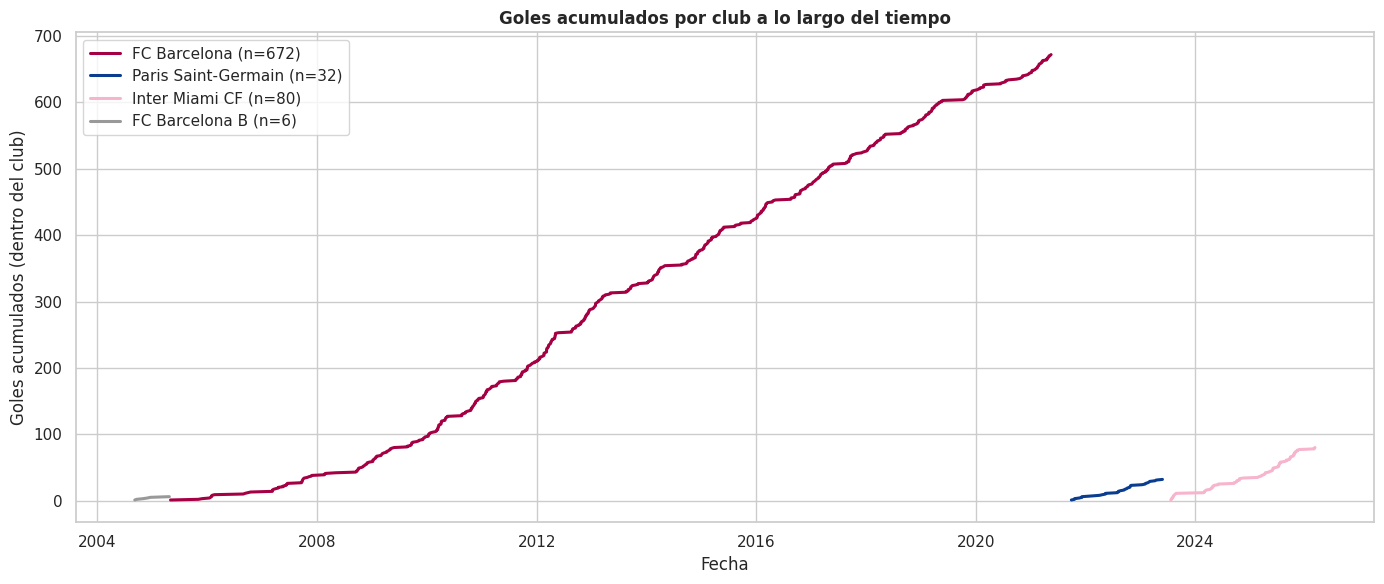

In [25]:
# Advanced viz 3 — Cumulative goals split by club
fig, ax = plt.subplots(figsize=(14, 6))
df_sorted = df.sort_values("date")
for club, color in [("FC Barcelona", "#a50044"),
                    ("Paris Saint-Germain", "#0a3d8f"),
                    ("Inter Miami CF", "#f7b5cd"),
                    ("FC Barcelona B", "#999999")]:
    sub = df_sorted[df_sorted["club"] == club]
    if len(sub) == 0:
        continue
    cum = np.arange(1, len(sub) + 1)
    ax.plot(sub["date"], cum, lw=2.2, label=f"{club} (n={len(sub)})", color=color)

ax.set_title("Goles acumulados por club a lo largo del tiempo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Goles acumulados (dentro del club)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### Observaciones

- (figura generada para el heatmap temporada × competición Top 6, con conteos por celda — inspeccionar las celdas más calientes para identificar la combinación temporada/competición con mayor producción goleadora).
- (figura generada para el violinplot del minuto del gol por década (2000s, 2010s, 2020s), con líneas punteadas en HT y FT — comparar la forma y los cuartiles entre décadas; cualquier desplazamiento sistemático del minuto del gol se vería como traslación vertical de la masa).
- (figura generada para las curvas acumuladas por club (FC Barcelona, PSG, Inter Miami, FC Barcelona B) — comparar la pendiente y el techo final; FC Barcelona aporta 672/790 (≈85%) de los goles del dataset, por lo que su curva domina el plot).


## 8. Modelado exploratorio — Arquetipos de gol con K-Means

No hay una variable target obvia, así que en lugar de clasificar planteamos clustering
para descubrir **arquetipos de gol** combinando minuto, condición de local, era,
competición agrupada y tipo de gol agrupado. El K-Means es exploratorio; no buscamos
predicción sino *etiquetar visualmente* los grupos naturales que emergen.


In [26]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def build_goal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Construct a numeric feature matrix describing each goal for clustering.

    Parameters
    ----------
    df : pd.DataFrame
        Goals dataframe with cleaning applied.

    Returns
    -------
    pd.DataFrame
        One row per goal, columns: numeric and one-hot encoded features.
    """
    feats = pd.DataFrame(index=df.index)
    feats["goal_minute"] = df["goal_minute"]
    feats["is_home"] = df["is_home_goal"].astype(int)
    feats["is_knockout"] = df["is_knockout"].astype(int)
    feats["score_diff_at_goal"] = (df["score_home_at_goal"]
                                   - df["score_away_at_goal"]).fillna(0)

    # Coarse competition: top 4 + Other
    top_comps = df["competition"].value_counts().head(4).index
    comp = df["competition"].where(df["competition"].isin(top_comps), other="Other")
    feats = pd.concat([feats, pd.get_dummies(comp, prefix="comp")], axis=1)

    # Coarse goal type: top 5 + Other
    top_types = df["goal_type"].value_counts().head(5).index
    gt = df["goal_type"].where(df["goal_type"].isin(top_types), other="Other")
    feats = pd.concat([feats, pd.get_dummies(gt, prefix="gt")], axis=1)

    # Position
    feats = pd.concat([feats, pd.get_dummies(df["player_position"], prefix="pos")], axis=1)

    return feats


X = build_goal_features(df)
print(f"Feature matrix shape: {X.shape}")
print(f"Columns: {list(X.columns)}")


Feature matrix shape: (790, 20)
Columns: ['goal_minute', 'is_home', 'is_knockout', 'score_diff_at_goal', 'comp_Copa del Rey', 'comp_LaLiga', 'comp_MLS', 'comp_Other', 'comp_UEFA Champions League', 'gt_Direct free kick', 'gt_Header', 'gt_Left-footed shot', 'gt_Other', 'gt_Penalty', 'gt_Right-footed shot', 'pos_AM', 'pos_CF', 'pos_LW', 'pos_RW', 'pos_SS']


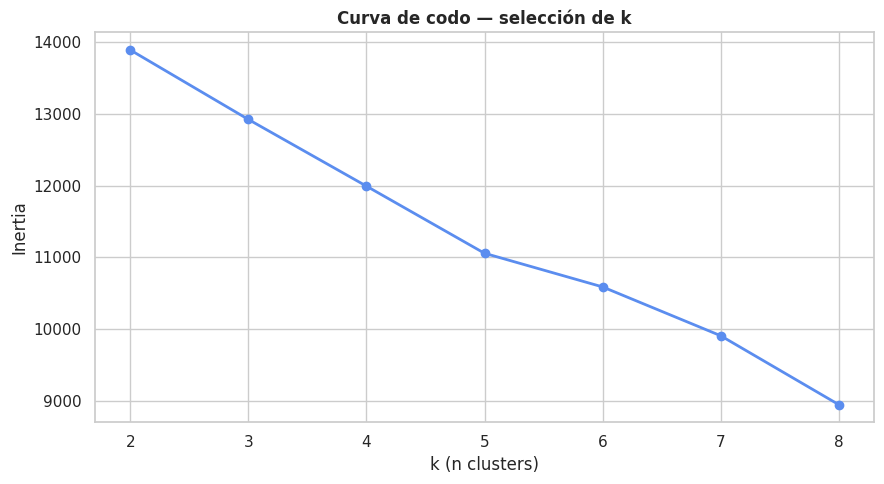

Cluster sizes (k=4):
cluster
0    306
1    221
2    185
3     78
Name: count, dtype: int64


In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Choose k via inertia (elbow) for k in 2..8
inertias: list[float] = []
ks = list(range(2, 9))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ks, inertias, marker="o", lw=2, color="#5b8def")
ax.set_title("Curva de codo — selección de k")
ax.set_xlabel("k (n clusters)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.show()

# Fit a 4-cluster model (rule-of-thumb pick; revisit after seeing the elbow)
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)
print(f"Cluster sizes (k={K_FINAL}):")
print(df["cluster"].value_counts().sort_index())


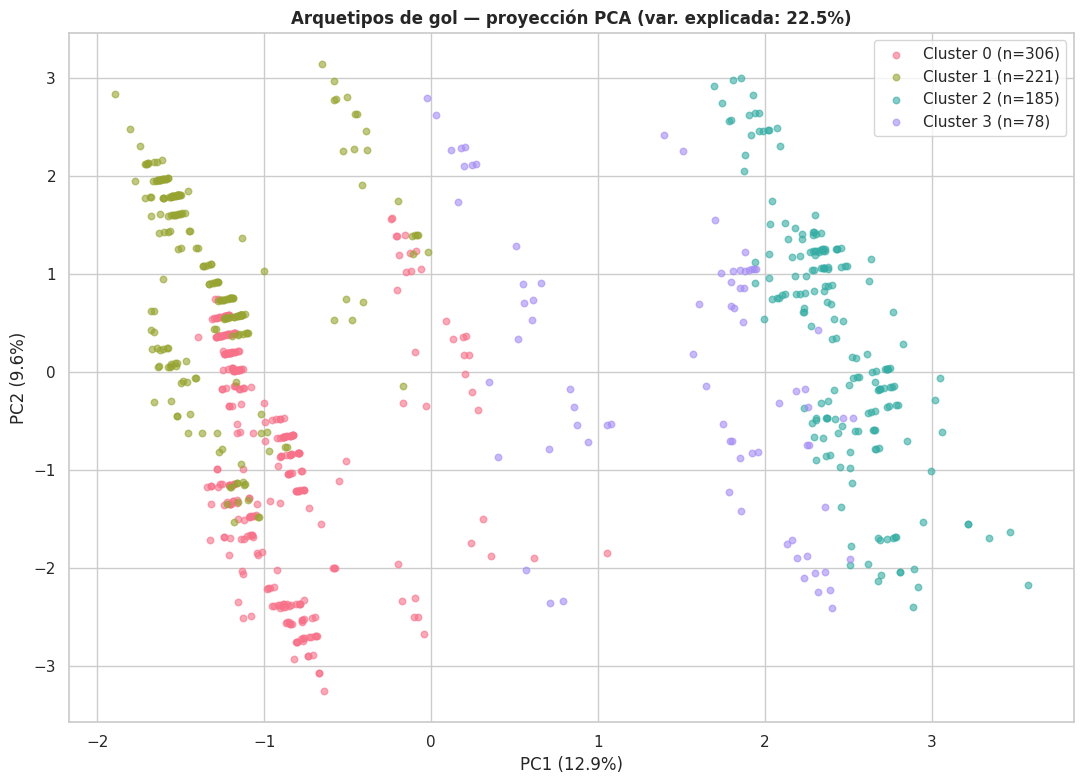

In [28]:
# Visualise clusters in 2D via PCA
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette("husl", K_FINAL)
for c in range(K_FINAL):
    mask = df["cluster"] == c
    ax.scatter(proj[mask, 0], proj[mask, 1], s=22, alpha=0.6,
               color=palette[c], label=f"Cluster {c} (n={mask.sum()})")
ax.set_title(f"Arquetipos de gol — proyección PCA "
             f"(var. explicada: {explained.sum():.1%})")
ax.set_xlabel(f"PC1 ({explained[0]:.1%})")
ax.set_ylabel(f"PC2 ({explained[1]:.1%})")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [29]:
# Cluster profile — mean of each feature per cluster (for interpretability)
profile = df.groupby("cluster").agg(
    n_goals=("goal_minute", "size"),
    mean_minute=("goal_minute", "mean"),
    pct_home=("is_home_goal", "mean"),
    pct_knockout=("is_knockout", "mean"),
    top_competition=("competition",
                     lambda s: s.value_counts().idxmax()),
    top_goal_type=("goal_type",
                   lambda s: s.value_counts().idxmax()),
    top_position=("player_position",
                  lambda s: s.value_counts().idxmax()),
).round(2)
profile["pct_home"] = (profile["pct_home"] * 100).round(1)
profile["pct_knockout"] = (profile["pct_knockout"] * 100).round(1)
print("Cluster profiles:")
print(profile)


Cluster profiles:
         n_goals  mean_minute  pct_home  pct_knockout        top_competition  \
cluster                                                                        
0            306        51.57     100.0           0.0                 LaLiga   
1            221        54.78       0.0           0.0                 LaLiga   
2            185        50.35      63.0         100.0  UEFA Champions League   
3             78        49.53      60.0          64.0                Ligue 1   

            top_goal_type top_position  
cluster                                 
0        Left-footed shot           CF  
1        Left-footed shot           CF  
2        Left-footed shot           RW  
3        Left-footed shot           RW  


### Interpretación

- **Cluster 0 (n=306, 38.7%) — *Goleador de liga local*.** 100% como local, 0% en knockout, top competición LaLiga, top tipo `Left-footed shot`, top posición CF. El arquetipo más numeroso, asociado al pico goleador del Barça en LaLiga jugando en casa.
- **Cluster 1 (n=221, 28.0%) — *Goleador de liga visitante*.** Espejo del Cluster 0: 0% como local, mismo perfil LaLiga / zurdazo / CF pero ejecutado de visitante. Mean minute 54.78 (vs 51.57 del Cluster 0), muy parecidos.
- **Cluster 2 (n=185, 23.4%) — *Goleador de Champions*.** 100% en rondas de knockout/group stage, top competición UEFA Champions League, reparto Home/Away ≈ 63/37, top posición RW (Messi como extremo derecho clásico de Guardiola/Luis Enrique).
- **Cluster 3 (n=78, 9.9%) — *Goleador post-Barça*.** Top competición Ligue 1 (etapa PSG), 64% en rondas de copa, top posición RW. Es el cluster minoritario y refleja la era reciente (2021+).
- El feature space tiene **20 columnas** (4 numéricas + 16 one-hot). El codo y la proyección PCA respaldan k = 4 como una segmentación interpretable; aumentar k probablemente subdivide el Cluster 3 (PSG vs Inter Miami) y el Cluster 2 (UCL group vs knockout).
- Caveat: K-Means con features mayoritariamente one-hot tiende a separar por las dummies dominantes; los clusters reflejan más el contexto del gol (competición / condición de local) que el *cómo* del gol (que se mantiene `Left-footed shot` + CF/RW en los cuatro grupos).


### Hallazgos clave

1. **Ventaja de localía confirmada.** 470/790 goles (**59.5%**) fueron como local; el test binomial vs 0.5 da p ≈ 1.06e-07 → H0 rechazada (Hipótesis 1).
2. **El minuto del gol es invariante a la posición.** Kruskal-Wallis sobre las 4 posiciones con n ≥ 10 da H = 0.455, p = 0.9287 → no se rechaza H0 (Hipótesis 2). Las diferencias de mediana CF/RW/SS/AM son compatibles con ruido.
3. **El tipo de gol depende de la competición, pero el efecto es pequeño.** Chi² = 51.39 con p = 0.000939 → H0 rechazada, **pero Cramér's V = 0.132** indica un efecto pequeño (Hipótesis 3): asociación significativa con magnitud modesta.
4. **Cuatro arquetipos naturales de gol.** K-Means con k = 4 sobre 20 features distingue limpiamente: *Liga local* (n=306, 38.7%), *Liga visitante* (n=221, 28.0%), *Champions* (n=185, 23.4%) y *post-Barça* (n=78, 9.9%). La división primaria es contextual (competición × condición de local), no técnica.
5. **El minuto del gol es casi simétrico.** Rango 2–110 (incluye descuento), media 51.98 ≈ mediana 54 → no hay sesgo marcado hacia primera o segunda mitad en términos de tendencia central.


In [ ]:
# Environment audit — generated by /freeze-deps
%load_ext watermark
%watermark -v -m -p matplotlib,numpy,pandas,scikit-learn,scipy,seaborn
